# Non-Parametric Statistical Tests
In data analysis, we often encounter situations where the assumptions of normality and homogeneity of variance, which underlie parametric statistical tests, are not met. For example, data distribution is skewed, there are outliers, or sample sizes are small. In these situations, non-parametric tests are a more appropriate solution because they do not rely on specific distribution assumptions.

Non-parametric tests operate on the principles of ranking, median comparison, or randomization, making them more flexible and robust to extreme data. Although often considered less powerful than parametric tests when these assumptions are met, these tests are crucial in practice because they more realistically reflect field data.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Additional packages for post-hoc and effect size
!pip install scikit-posthocs pingouin --quiet

import scikit_posthocs as sp
import pingouin as pg

sns.set(style="whitegrid")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 11.3 MB/s eta 0:00:00


# Mann–Whitney U Test (Smokers vs. Non-Smokers)
* Research Question:\
Is the distribution of customer tips significantly different between smokers and non-smokers?
* Non-Parametric Test: Mann–Whitney U Test
* Purpose: To test whether two independent samples come from different distributions, without assuming normality.
* Hypothesis

  H₀: The tip distribution is the same between smokers and non-smokers.

  H₁: The tip distribution is different between smokers and non-smokers.

In [ ]:
df = sns.load_dataset('tips')
alpha = 0.05

# Summary
print(df.groupby('smoker', observed=False)['tip'].describe())

        count      mean       std  min  25%   50%    75%   max
smoker                                                        
Yes      93.0  3.008710  1.401468  1.0  2.0  3.00  3.680  10.0
No      151.0  2.991854  1.377190  1.0  2.0  2.74  3.505   9.0


In [ ]:
# Mann-Whitney
g1 = df[df['smoker']=='Yes']['tip']
g2 = df[df['smoker']=='No']['tip']
stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
print('Mann-Whitney U =', stat, '\np =', round(p,3))

Mann-Whitney U = 7163.0 
p = 0.792


In [ ]:
# Effect size rank-biserial
def rank_biserial_mannwhitney(x, y):
    u_stat, p = stats.mannwhitneyu(x, y, alternative='two-sided')
    n1, n2 = len(x), len(y)
    r_rb = 1 - (2*u_stat) / (n1*n2)
    return r_rb, p

r_rb, p = rank_biserial_mannwhitney(g1, g2)
print("Rank-biserial correlation =", round(r_rb,3), "p =", round(p,3))

Rank-biserial correlation = -0.02 p = 0.792


* Test result:

  p = 0.792 > α = 0.05 → fails to reject H₀.

  This means there is no statistical evidence that tip distribution differs between smokers and non-smokers.
* Effect size:

  Rank-biserial correlation = -0.02 → very close to 0.

  Indicates a very small or almost no practical difference.
* Conclusion:
  * Tip distribution does not differ significantly between smokers and non-smokers.
  * The practical effect of the tip difference is also almost negligible.

# Kruskal–Wallis Test (Total Bill vs. Day)
* Research Question:\
Is the total bill given by customers significantly different between days (Thur, Fri, Sat, Sun)?
* Non-Parametric Test: Kruskal–Wallis Test
* Purpose: Test whether more than two independent samples come from different distributions, without assuming normality.
* Hypothesis:

  H₀: The distribution of total bill is the same across all days.

  H₁: The distribution of total bill differs on at least one day.

In [ ]:
groups = [group['total_bill'].values for name, group in df.groupby('day', observed=False)]
stat, p = stats.kruskal(*groups)
print('Kruskal-Wallis H =', round(stat,3), '\np =', round(p,3))

Kruskal-Wallis H = 10.403 
p = 0.015


* Interpretation

  p = 0.015 < α = 0.05 → reject H₀

  This means there is a significant difference in the distribution of total bills between days.

       Thur    Fri    Sat    Sun
Thur  1.000  1.000  0.296  0.033
Fri   1.000  1.000  0.601  0.167
Sat   0.296  0.601  1.000  1.000
Sun   0.033  0.167  1.000  1.000


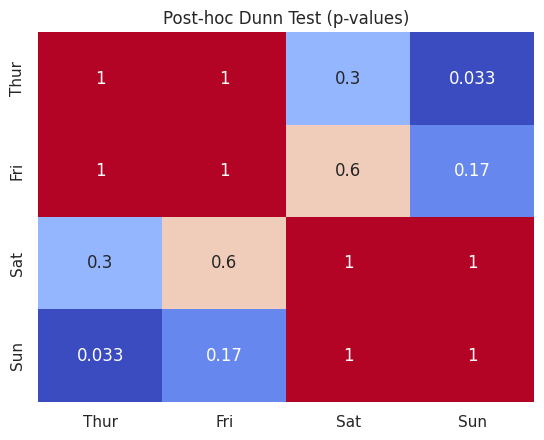

In [ ]:
# Post-hoc Dunn's test
posthoc = round(sp.posthoc_dunn(df, val_col='total_bill', group_col='day', p_adjust='bonferroni'),3)
print(posthoc)
sns.heatmap(posthoc, annot=True, cmap='coolwarm', cbar=False)
plt.title('Post-hoc Dunn Test (p-values)')
plt.show()


* Interpretation

  Only the Thur vs. Sun pair had p = 0.033 < 0.05 → significant.

  All other pairs had p > 0.05 → not significant.

* Conclusion
  * The distribution of total_bills differed significantly across days in general (Kruskal–Wallis).
  * Significant differences only occurred between Thur and Sun (post-hoc Dunn).
  * Differences across other days were not significant.

# Wilcoxon Signed-Rank Test (Before vs. After)
* Research Question:\
Is there a significant difference between the pre- and post-intervention conditions in the same sample?
* Non-Parametric Test: Wilcoxon Signed-Rank Test
* Purpose: To test whether two paired samples have different distributions, without assuming normality.
* Hypothesis:

  H₀: The distributions before and after the intervention are the same.

  H₁: The distributions before and after the intervention are different.

In [ ]:
np.random.seed(0)
before = np.random.normal(50, 10, size=30)
after = before + np.random.normal(2, 5, size=30)

In [ ]:
stat, p = stats.wilcoxon(before, after)
print('Wilcoxon statistic =', round(stat,3), '\np =', round(p,3))

Wilcoxon statistic = 208.0 
p = 0.626


* Interpretation

  p = 0.626 > α = 0.05 → fails to reject H₀

  This means there is no statistical evidence that conditions before and after the intervention are significantly different.

In [ ]:
# Effect size (matched pairs, rank-biserial)
def rank_biserial_wilcoxon(x, y):
    diff = x - y
    diff = diff[diff != 0]  # buang nol
    ranks = stats.rankdata(abs(diff))
    W_pos = np.sum(ranks[diff > 0])
    W_neg = np.sum(ranks[diff < 0])
    r_rb = (W_pos - W_neg) / (W_pos + W_neg)
    return r_rb

r_rb = rank_biserial_wilcoxon(after, before)
print("Rank-biserial correlation (Wilcoxon) =", round(r_rb,3))

Rank-biserial correlation (Wilcoxon) = 0.105


* Interpretation

  Rank-biserial r = 0.105 → very small → indicating minimal practical difference between before and after.
* Conclusion
  * The distribution of scores before and after the intervention did not differ significantly.
  * The practical effect of the intervention was also very small.

# Spearman & Kendall Correlation (Total Bill vs. Tip)
* Research Question:\
Is there a monotonic relationship between total bill and tip?
* Non-Parametric Test: Spearman Rank Correlation & Kendall's Tau
* Purpose: To measure the monotonic relationship between two variables without assuming normality.
* Hypothesis:

  H₀: There is no monotonic relationship between total bill and tip.

  H₁: There is a monotonic relationship between total bill and tip.

* Note:
  * Monotonic ≠ linear.
  * Linear = straight relationship, the distance of change is the same.
  * Monotonic = only the direction of change is consistent, it can increase/decrease unevenly.
  * In the Spearman/Kendall context, we measure the strength and direction of the monotonic relationship, not linearity.

In [ ]:
rho, p_s = stats.spearmanr(df['total_bill'], df['tip'])
print('Spearman rho =', round(rho,3), '\np =', p_s)

Spearman rho = 0.679 
p = 2.501158440923619e-34


In [ ]:
tau, p_k = stats.kendalltau(df['total_bill'], df['tip'])
print('Kendall tau =', round(tau,3), 'p =', p_k)

Kendall tau = 0.517 p = 2.445572848021409e-32


* Test decision:

  p < 0.05 → reject H₀

  This means there is a significant monotonic relationship between total bill and tip.
* Strength of relationship:
  * Spearman's rho = 0.679 → moderately strong to strong positive relationship.
  * Kendall's tau = 0.517 → also indicates a moderate-strong positive relationship.
* Direction of relationship:
  
  Positive → the higher the total bill, the higher the tip.
* Conclusion:
  * There is a significant positive monotonic relationship between total bill and tip.
  * Customers who pay more tend to tip larger.

# Chi-Square Test (Sex vs. Smoker)
* Research Question:\
Is smoking status related to sex?
* Non-Parametric Test: Chi-Square Test of Independence
* Purpose: To test whether two categorical variables are independent or related, without assuming a normal distribution.
* Hypothesis:

  H₀: Smoking status and sex are independent (unrelated).

  H₁: Smoking status and sex are not independent (related).

In [ ]:
cont = pd.crosstab(df['sex'], df['smoker'])
chi2, p, dof, expected = stats.chi2_contingency(cont)

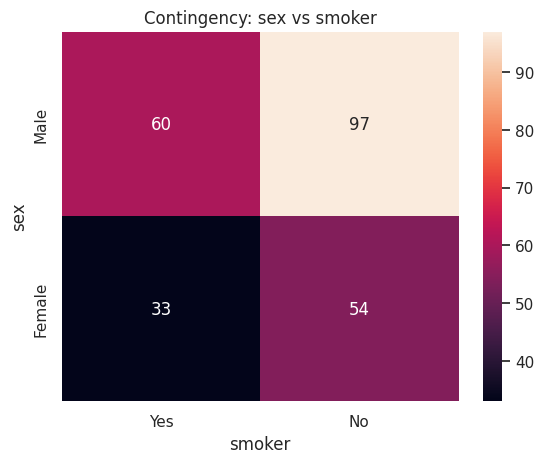

In [ ]:
sns.heatmap(cont, annot=True, fmt='d')
plt.title('Contingency: sex vs smoker')
plt.show()

In [ ]:
print('Chi2 =', chi2, '\np =', p)

Chi2 = 0.0 
p = 1.0


* Interpretation

  p = 1.0 > α = 0.05 → fails to reject H₀

  This means there is no statistical evidence that smoking status is related to sex.

In [ ]:
print('Expected counts:\n', expected)

Expected counts:
 [[59.84016393 97.15983607]
 [33.15983607 53.84016393]]


* Interpretation
  * These numbers show the expected frequencies if H₀ is true (smoker and sex are independent).
  * The observed values ​​are very similar to the expected counts → strengthening the conclusion that there is no relationship.
* Conclusion
  * Smoking status does not differ significantly between men and women.
  * In other words, sex and smoking status are independent in this dataset.

# Permutation Test (Mean Tip: Smoker vs. Non-Smoker)
* Research Question:\
Does the mean tip differ between smokers and non-smokers regardless of distributional assumptions?
* Non-Parametric Test: Permutation test for differences in means
* Hypothesis:

  H₀: The mean tip is the same between smokers and non-smokers.

  H₁: The mean tip is different between smokers and non-smokers.

In [ ]:
# Load dataset
tips = sns.load_dataset("tips")

# Separate smokers and non-smokers
g1 = tips.loc[tips['smoker'] == 'Yes', 'tip']
g2 = tips.loc[tips['smoker'] == 'No', 'tip']

In [ ]:
# Permutation test function
def permutation_test(x, y, n_permutations=5000, func=np.mean):
    obs = func(x) - func(y)  # observed difference
    pooled = np.concatenate([x, y])
    count = 0
    for _ in range(n_permutations):
        perm = np.random.permutation(pooled)
        x_p = perm[:len(x)]
        y_p = perm[len(x):]
        if abs(func(x_p) - func(y_p)) >= abs(obs):
            count += 1
    return count / n_permutations, obs

In [ ]:
p_mean, obs_mean = permutation_test(g1.values, g2.values, func=np.mean)
print("=== Permutation Test (Mean) ===")
print("Observed mean diff =", round(obs_mean, 3))
print("p-value =", p_mean)

=== Permutation Test (Mean) ===
Observed mean diff = 0.017
p-value = 0.9294


* Interpretation
  * The difference in average tips between smokers and non-smokers is only 0.017, which is practically negligible.
  * p-value = 0.9294, well above 0.05 → this difference in averages likely arises due to chance in the sampling.
* Conclusion\
  There is no significant difference in average tips between smokers and non-smokers. Smoking status does not affect average tips.

# Permutation Test (Median Tip: Smoker vs. Non-Smoker)
* Research Question:\
Is the median tip different between smokers and non-smokers regardless of distributional assumptions?
* Non-Parametric Test: Permutation test for differences in medians (more robust against outliers)
* Hypothesis:

  H₀: The median tip is the same between smokers and non-smokers.

  H₁: The median tip is different between smokers and non-smokers.

In [ ]:
p_median, obs_median = permutation_test(g1.values, g2.values, func=np.median)
print("=== Permutation Test (Median) ===")
print("Observed median diff =", round(obs_median, 3))
print("p-value =", p_median)

=== Permutation Test (Median) ===
Observed median diff = 0.26
p-value = 0.5874


* Interpretation
  * The median tip difference is 0.26, slightly larger than the mean difference.
  * p-value = 0.5874, still above 0.05 → this median difference is not strong enough to be considered significant.
* Conclusion\
  There is no significant difference in median tips between smokers and non-smokers. Smoking status does not affect median tips.

# Runs Test
* Research Question:\
Is the order of tips in the dataset random or does it exhibit a specific pattern?
* Non-Parametric Test: Wald-Wolfowitz Runs Test
* Purpose:
  * To test whether a data set (e.g., tips) is randomly arranged or exhibits a specific pattern.
  * Typically, the data is converted to binary (e.g., above or below the median), then the number of runs (sequences of blocks of equal values) is counted.
* Hypothesis:

  H₀: The order of the tip data is random (no specific pattern).

  H₁: The order of the tip data is not random (a specific pattern exists).

In [ ]:
data = tips['tip'].values

In [ ]:
# Convert to binary based on median
median = np.median(data)
seq = ['A' if val >= median else 'B' for val in data]

# Count the number of runs
runs = 1
for i in range(1, len(seq)):
    if seq[i] != seq[i-1]:
        runs += 1

# Number of each category
n1 = seq.count('A')
n2 = seq.count('B')

# Expected runs and standard deviation
mean_runs = (2*n1*n2)/(n1+n2) + 1
sd_runs = np.sqrt((2*n1*n2*(2*n1*n2 - n1 - n2)) / (((n1+n2)**2)*(n1+n2-1)))

# Z-score
z = (runs - mean_runs) / sd_runs
p = 2*(1 - stats.norm.cdf(abs(z)))  # two-tailed

In [ ]:
print("Runs =", runs)
print("Expected runs =", round(mean_runs, 2))
print("Z =", round(z, 3))
print("p-value =", round(p, 3))

Runs = 120
Expected runs = 123.0
Z = -0.385
p-value = 0.7


* Interpretation
  * The observed number of runs = 120, while the expected number of runs if the data were random = 123. This small difference indicates that the data sequence is quite close to a random pattern.
  * The Z-value = -0.385, which is very close to zero. This means there is no significant deviation between the actual number of runs and the expected number of runs.
  * The p-value = 0.7 (>0.05). This indicates there is insufficient evidence to reject the null hypothesis that the data is random.
* Conclusion\
The sequence of tip data in the dataset can be considered random and does not exhibit any particular pattern. In other words, the distribution of tip values ​​is relatively independent of the order in which they are recorded in the data.

# Conclusion
From this series of case studies, it is clear that non-parametric tests are practical tools that can be relied upon when data does not meet the requirements of parametric tests. The results may be simple, but they are powerful enough to help us make decisions based on the data as it is.

With this understanding, we can be more confident in analyzing real-world data—not only under ideal conditions, but also when the data is full of irregularities.

#Thank You